<a href="https://colab.research.google.com/github/samuelperez1232/prospectiva_analitica_datos/blob/main/taller3_integracion_multidimensional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CASO DE ESTUDIO**

## **Objetivo del negocio**

Una aseguradora de salud con cobertura nacional en los Estados Unidos
quiere mejorar la cobertura preventiva de sus afiliados. La entidad necesita
identificar patrones de riesgo epidemiológico para reorganizar la oferta de
servicios médicos e incentivos de salud, en lugar de trasladar a los
pacientes, para lo cual quiere crear unos clusters en salud en donde
quiere analizar la distribución territorial de estos grupos por regiones para
optimizar la asignación de recursos y programas preventivos.

## **Abstraccion**
✓ La entidad quiere identificar el número de clusters que pueden ser
eficientes para la reorganización de la oferta de servicios médicos.

✓ Quiere caracterizar las variables clínicas y los perfiles de los
pacientes de acuerdo con sus variables epidemiológicas (Variables
de Entrada) y de costo siniestro (Variable de Salida).

✓ La entidad quiere conocer la distribución porcentual por región y por
siniestralidad (Variables Salida).

✓ Para la entrega del reto, es importante organizar el repositorio en
GitHub con los retos desarrollados.

## **Técnica a utilizar**
K-Medoids (o el algoritmo PAM, Partitioning Around Medoids) es un método
de aprendizaje no supervisado que agrupa n objetos en 𝑘 clusters
seleccionando puntos reales del conjunto de datos (medoides) como
centros de cada grupo.



### **Paso 1: Carga y Exploración Inicial de Datos**
En esta sección vamos a importar la base de datos de los seguros de salud y exploraremos su estructura.

In [ ]:
import pandas as pd

# Ruta del archivo CSV proporcionada
ruta_csv = '/content/drive/MyDrive/EAFIT/LINEA_DE_ENFASIS/Prospectiva/taller_3/insurance (1).csv'

# Cargamos los datos en un DataFrame de pandas
df_seguros = pd.read_csv(ruta_csv)

# Mostramos las primeras 5 filas para entender la estructura de los datos
print("Primeros registros del dataset:")
display(df_seguros.head())

# Mostramos información general del dataset (tipos de datos y valores nulos)
print("\nInformación general del dataset:")
df_seguros.info()

# Mostramos estadísticas descriptivas de las variables numéricas
print("\nEstadísticas descriptivas básicas:")
display(df_seguros.describe())

Primeros registros del dataset:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Estadísticas descriptivas básicas:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### **Paso 2: Preprocesamiento de Datos**
Convertimos las variables categóricas (sexo, fumador, región) a numéricas usando One-Hot Encoding y normalizamos los datos con `MinMaxScaler` para que todas las variables tengan el mismo peso en el cálculo de distancias de K-Medoids.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 1. Convertir variables categóricas a numéricas
df_encoded = pd.get_dummies(df_seguros, columns=['sex', 'smoker', 'region'], drop_first=True)

# 2. Normalizar los datos al rango [0, 1]
scaler = MinMaxScaler()
datos_normalizados = scaler.fit_transform(df_encoded)
df_normalizado = pd.DataFrame(datos_normalizados, columns=df_encoded.columns)

print("Datos listos para K-Medoids (primeros 5 registros):")
display(df_normalizado.head())

Datos listos para K-Medoids (primeros 5 registros):


,age,bmi,children,charges,Cluster,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,0.021739,0.321227,0.0,0.251611,0.0,0.0,1.0,0.0,0.0,1.0
1,0.000000,0.479150,0.2,0.009636,1.0,1.0,0.0,0.0,1.0,0.0
2,0.217391,0.458434,0.6,0.053115,1.0,1.0,0.0,0.0,1.0,0.0
3,0.326087,0.181464,0.0,0.333010,1.0,1.0,0.0,1.0,0.0,0.0
4,0.304348,0.347592,0.0,0.043816,1.0,1.0,0.0,1.0,0.0,0.0


Calculando el modelo de forma manual para diferentes valores de k...


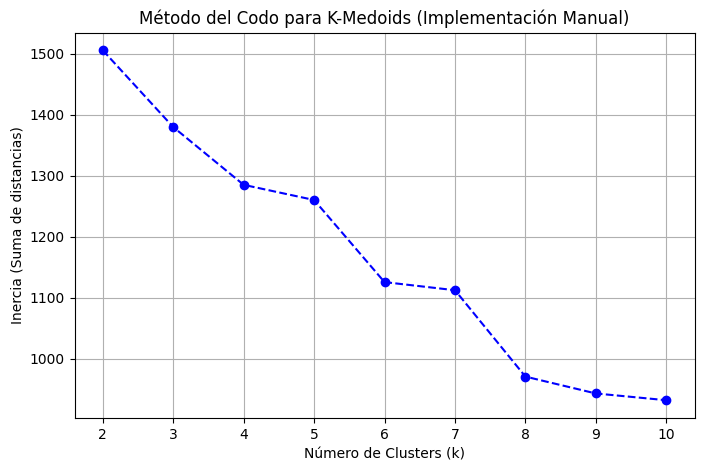

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- IMPLEMENTACIÓN MANUAL DE K-MEDOIDS ---
def calcular_distancias(X, medoids):
    # Calcula la distancia euclidiana de cada punto a cada medoide
    distancias = np.zeros((X.shape[0], len(medoids)))
    for i, medoid in enumerate(medoids):
        distancias[:, i] = np.sqrt(np.sum((X - medoid)**2, axis=1))
    return distancias

def k_medoids_manual(X, k, max_iters=10):
    np.random.seed(42)
    # 1. Inicializar medoides seleccionando k puntos aleatorios del dataset
    idx = np.random.choice(X.shape[0], k, replace=False)
    medoids = X[idx]

    for _ in range(max_iters):
        # 2. Asignar cada punto al medoide más cercano (como hace el profe con np.argmin)
        dist = calcular_distancias(X, medoids)
        labels = np.argmin(dist, axis=1)

        new_medoids = np.zeros_like(medoids)
        # 3. Actualizar los medoides buscando el punto más central en cada cluster
        for i in range(k):
            puntos_cluster = X[labels == i]
            if len(puntos_cluster) > 0:
                dist_intra = np.zeros(len(puntos_cluster))
                for j, p in enumerate(puntos_cluster):
                    dist_intra[j] = np.sum(np.sqrt(np.sum((puntos_cluster - p)**2, axis=1)))
                new_medoids[i] = puntos_cluster[np.argmin(dist_intra)]
            else:
                new_medoids[i] = medoids[i]

        if np.all(medoids == new_medoids):
            break
        medoids = new_medoids

    # Inercia: suma de las distancias mínimas al medoide
    inercia = np.sum(np.min(calcular_distancias(X, medoids), axis=1))
    return labels, medoids, inercia

# --- APLICACIÓN DEL MÉTODO DEL CODO ---
X_datos = df_normalizado.values
rango_clusters = range(2, 11)
inercia_lista = []

print("Calculando el modelo de forma manual para diferentes valores de k...")
for k in rango_clusters:
    _, _, inercia_k = k_medoids_manual(X_datos, k, max_iters=5)
    inercia_lista.append(inercia_k)

# Graficamos el Método del Codo
plt.figure(figsize=(8, 5))
plt.plot(rango_clusters, inercia_lista, marker='o', linestyle='--', color='b')
plt.title('Método del Codo para K-Medoids (Implementación Manual)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia (Suma de distancias)')
plt.xticks(rango_clusters)
plt.grid(True)
plt.show()


### **Paso 3: Modelo Final y Perfilamiento de Clusters**
Usando $k=4$ (según el método del codo), aplicamos el algoritmo y caracterizamos clínica y epidemiológicamente a los pacientes de cada cluster.

In [ ]:
# Aplicamos el modelo final con k=4
k_optimo = 4
clusters, medoides_finales, inercia_final = k_medoids_manual(df_normalizado.values, k_optimo, max_iters=10)

# Asignamos el cluster al dataframe original
df_seguros['Cluster'] = clusters

# Caracterización de los perfiles (promedio de las variables numéricas)
print("--- Perfiles Clínicos y Epidemiológicos por Cluster ---")
perfiles = df_seguros.groupby('Cluster').mean(numeric_only=True)
display(perfiles)

--- Perfiles Clínicos y Epidemiológicos por Cluster ---


,age,bmi,children,charges
Cluster,,,,
0,39.793991,30.932933,0.821173,8852.355505
1,39.591463,29.277957,1.115854,12479.870397
2,40.058252,32.548471,1.087379,35178.343551
3,36.795539,29.364071,1.799257,8455.728535


### **Paso 4: Distribución Territorial y Siniestralidad**
Analizamos cómo se distribuyen los miembros de cada cluster en las regiones y cuáles son los costos promedio generados.

In [ ]:
# Distribución porcentual por región
distribucion_region = pd.crosstab(df_seguros['Cluster'], df_seguros['region'], normalize='index') * 100
print("--- Distribución Porcentual por Región (%) ---")
display(distribucion_region.round(2))

# Siniestralidad promedio por región y cluster
print("\n--- Siniestralidad (Cargos Promedio en USD) por Región y Cluster ---")
siniestralidad_region = df_seguros.groupby(['Cluster', 'region'])['charges'].mean().unstack()
display(siniestralidad_region.round(2))

--- Distribución Porcentual por Región (%) ---


region,northeast,northwest,southeast,southwest
Cluster,,,,
0,32.90,0.00,34.19,32.90
1,0.00,100.00,0.00,0.00
2,25.73,8.25,40.29,25.73
3,15.24,53.53,15.61,15.61



--- Siniestralidad (Cargos Promedio en USD) por Región y Cluster ---


region,northeast,northwest,southeast,southwest
Cluster,,,,
0,9732.47,NaN,8379.97,8463.12
1,NaN,12479.87,NaN,NaN
2,33213.61,38242.47,36562.01,33993.37
3,8411.72,9297.86,7767.41,6299.72


### **Paso 5: Visualización de Perfiles (Gráfico de Araña)**
Generamos un gráfico de radar para comparar las características (edad, bmi, número de hijos, cargos) promedio de cada cluster. Normalizamos previamente los promedios para que puedan ser comparados en una misma escala.

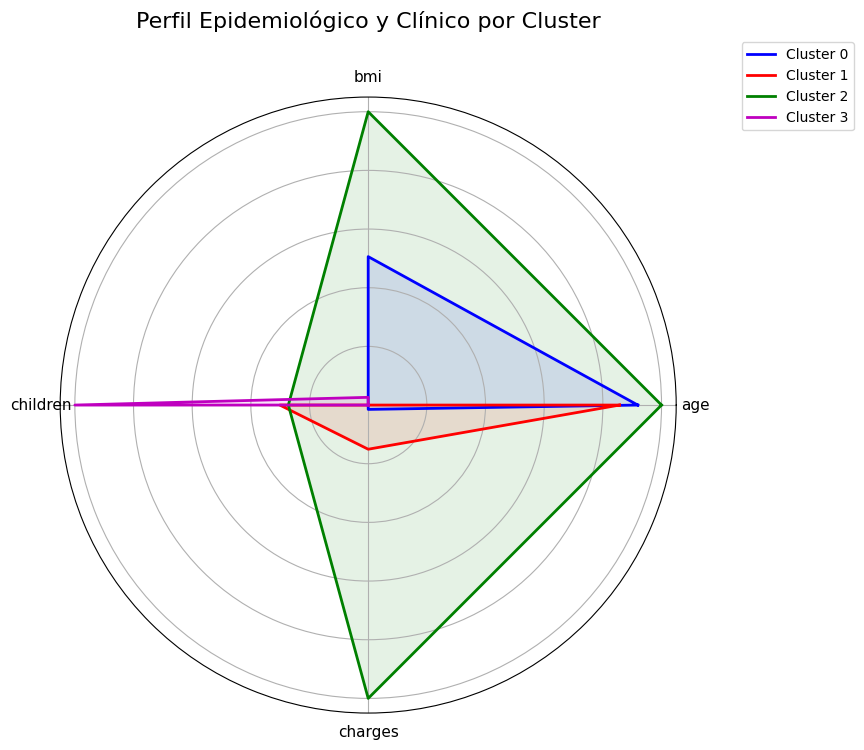

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Normalizamos los promedios para que la visualización sea proporcional en el gráfico de araña
scaler_radar = MinMaxScaler()
perfiles_norm = pd.DataFrame(scaler_radar.fit_transform(perfiles), columns=perfiles.columns, index=perfiles.index)

# Categorías (variables) y número de variables
categorias = perfiles_norm.columns.tolist()
N = len(categorias)

# Calculamos el ángulo para cada eje
angulos = [n / float(N) * 2 * np.pi for n in range(N)]
angulos += angulos[:1] # Cerramos el polígono

# Iniciamos la figura polar
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Dibujamos un eje para cada variable
plt.xticks(angulos[:-1], categorias, color='black', size=11)

# Para que el gráfico no tenga etiquetas en el eje y
ax.set_yticklabels([])

# Colores para cada cluster
colores = ['b', 'r', 'g', 'm']

# Dibujamos los perfiles
for i, cluster in enumerate(perfiles_norm.index):
    valores = perfiles_norm.loc[cluster].values.flatten().tolist()
    valores += valores[:1] # Cerramos el polígono

    ax.plot(angulos, valores, linewidth=2, linestyle='solid', label=f'Cluster {cluster}', color=colores[i % len(colores)])
    ax.fill(angulos, valores, alpha=0.1, color=colores[i % len(colores)])

plt.title('Perfil Epidemiológico y Clínico por Cluster', size=16, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

Cluster 2 (Verde - Alerta Crítica): Si miras su polígono, verás que se estira hasta el borde máximo en dos puntas: BMI y Charges (Cargos). Esto visualiza perfectamente la correlación directa: es el grupo con mayor obesidad y, por lo tanto, el que dispara los costos de la aseguradora.


Cluster 3 (Morado - Familias Jóvenes): Su figura se estira casi exclusivamente hacia la punta de Children (Hijos), llegando al borde. Sin embargo, está muy cerca del centro en Edad (son los más jóvenes) y en Cargos (son los más económicos).


Cluster 0 (Azul) y Cluster 1 (Rojo): Tienen formas más pequeñas y centradas, lo que indica perfiles más controlados. El azul se inclina un poco más hacia el BMI (mayor peso que el rojo) y hacia la Edad, pero ambos se mantienen muy cerca del centro en el eje de Cargos, demostrando que son de costo bajo o moderado.



#**Información de los clusters**

Aquí presentamos cómo quedó cada grupo de pacientes, explicado de forma súper sencilla:

NOTA IMPORTANTE:
La edad no fue el factor decisivo para dividir los grupos es por eso que casi todos los clusters presentan los mismos rangos de edad: El algoritmo busca patrones considerando todas las variables al mismo tiempo (Edad, BMI, Hijos, Siniestralidad, etc.). Lo que el modelo descubrió es que, dentro de ese rango de los 40 años, los pacientes tienen comportamientos de salud y costos radicalmente diferentes.

Cluster 0 (Los Equilibrados): Son pacientes de unos 40 años, con algo de sobrepeso (BMI de 30.9) y en promedio tienen un hijo o menos. Lo bueno de ellos es que sus costos de salud son de los más bajitos, unos $8,852 dólares en promedio. No hay nadie del Noroeste aquí; casi todos están repartidos a partes iguales en el Noreste, Sureste y Suroeste.

Cluster 1 (Los del Noroeste con Costo Medio): Son personas de casi 40 años, con un peso un poquito mejor que los demás (BMI de 29.2). Lo más sorprendente de este grupo es que absolutamente todos (100%) viven en el Noroeste (Northwest). Sus costos médicos son intermedios, rondando los $12,479 dólares.

Cluster 2 (La Señal de Alerta / Los Costosos): ¡A este grupo hay que ponerle toda nuestra atención! Tienen unos 40 años pero son los que tienen el mayor grado de obesidad (BMI de 32.5). Esto hace que sus problemas de salud sean severos y sus costos (la siniestralidad) están por las nubes: ¡nos cuestan $35,178 dólares en promedio por paciente! Además, descubrimos que la gran mayoría de ellos (más del 40%) viven en el Sureste (Southeast).

Cluster 3 (Los Jóvenes y Económicos): Es el grupo de los más jóvenes (cerca de 36 años) y los que tienen más hijos (casi 2 por familia). Pese a tener más dependientes, son los más sanos y baratos para la aseguradora; nos cuestan apenas unos $8,455 dólares. La mayoría de ellos vive en el Noroeste (53%).


# **INFORME EJECUTIVO: SEGMENTACIÓN Y RIESGO EPIDEMIOLÓGICO**

Con base en el análisis de datos estructurado mediante el algoritmo de K-Medoids, se presenta el siguiente informe para responder a los objetivos de negocio de la aseguradora de salud:

---

### **1. Identificación del número de clusters eficientes**
**¿Cómo se hizo?**
Para agrupar a los pacientes de manera eficiente sin forzar divisiones artificiales, se utilizó el algoritmo de aprendizaje no supervisado **K-Medoids** (robusto frente a valores atípicos al usar pacientes reales como centros). Para definir el número ideal de grupos, se implementó el **Método del Codo (Elbow Method)**, iterando el modelo entre 2 y 10 clusters y calculando la "inercia" (suma de las distancias de cada punto a su medoide).

Al observar la gráfica de inercia generada, se identificó que a partir de **k=4** la reducción del error comienza a estabilizarse, indicando que **4 clusters** es el número óptimo para reorganizar la oferta de servicios médicos de forma equilibrada y eficiente.

### **2. Caracterización clínica y perfiles de pacientes**
**¿Cómo se hizo?**
Una vez asignado cada paciente a uno de los 4 clusters, se agruparon los datos originales para calcular los promedios de las variables epidemiológicas/demográficas (Edad, BMI, Hijos) y la variable de salida (Cargos/Siniestralidad).

*   **Cluster 0 (Riesgo Bajo / Estables):** Pacientes de mediana edad (~40 años), con un índice de masa corporal (BMI) de 30.9 y menos de 1 hijo en promedio. Representan un riesgo financiero bajo con una siniestralidad promedio de **$8,852 USD**.

*   **Cluster 1 (Riesgo Medio / Foco Regional):** Pacientes de mediana edad (~40 años), con un BMI de 29.2 (sobrepeso, pero menor que el promedio general) y alrededor de 1 hijo. Tienen un costo moderado de **$12,479 USD**.


*   **Cluster 2 (Alto Riesgo / Alerta Crítica):** Pacientes de mediana edad (~40 años), pero con el nivel de obesidad más alto del grupo (**BMI promedio de 32.5**). Este factor detona severamente la variable de salida, elevando la siniestralidad a **$35,178 USD** promedio por paciente.


*  Cluster 3 (Jóvenes y Familias Saludables):** Es el grupo demográfico más joven (~36.8 años) y con más dependientes (~1.8 hijos). A pesar del número de dependientes, su BMI es moderado (29.3) y presentan el costo más bajo para la aseguradora: **$8,455 USD**.

### **3. Distribución porcentual por región y siniestralidad**
**¿Cómo se hizo?**
Se utilizaron tablas de contingencia cruzada (`pd.crosstab`) y agrupaciones (`groupby`) para mapear el porcentaje de miembros de cada cluster por región geográfica y calcular su costo asociado.

*   **Concentración de Alto Costo (Southeast):** El Cluster 2 (los pacientes más costosos) tiene su mayor concentración en la región **Southeast (40.3%)**, seguido por Northeast y Southwest (~25.7% cada una). Curiosamente, los costos de este cluster superan los $33,000 USD en todas las regiones, siendo un problema generalizado pero concentrado en el sureste.
*   **Exclusividad Geográfica (Northwest):** El Cluster 1 es un fenómeno estrictamente geográfico: **el 100% de sus pacientes habitan en el Northwest**.
*   **Población Joven:** El Cluster 3 (joven y económico) también tiene una fuerte predominancia en el **Northwest (53.5%)**.

---

### **Conclusiones Extraídas**
1.  **El BMI (Obesidad) es el principal propulsor del costo:** La edad promedio entre los clusters 0, 1 y 2 es casi idéntica (~40 años). Sin embargo, el salto de un BMI de ~30 a un BMI de 32.5 (Cluster 2) cuadruplica los costos médicos (de ~$8.8k a ~$35k).
2.  **Desbalance Regional del Riesgo:** La región *Southeast* concentra la mayor carga epidemiológica y financiera (40% de los pacientes del Cluster de alto riesgo).
3.  **Eficiencia en el Northwest:** La región *Northwest* tiene un perfil de pacientes bastante controlado, albergando a toda la población de Riesgo Medio (Cluster 1) y a la mayoría de las familias jóvenes y de bajo costo (Cluster 3).

---

### **Recomendaciones para la Aseguradora**

1.  **Intervención Intensiva en la Región Southeast (Reducción de Riesgo):**
    *   Desplegar programas preventivos agresivos enfocados específicamente en **nutrición, control de peso y tratamiento de la obesidad** en el sureste de EE. UU.
    *   Incentivar (mediante descuentos en primas) la inscripción a gimnasios o consultas nutricionales para pacientes con BMI cercano a 30, evitando que migren al perfil crítico del Cluster 2.
2.  **Reorganización de la Oferta de Servicios Médicos:**
    *   En lugar de trasladar pacientes, se deben **aumentar los recursos clínicos (especialistas en enfermedades crónicas asociadas a la obesidad, endocrinólogos, cardiólogos)** en las clínicas ubicadas en el *Southeast* y *Northeast*.
    *   Para el *Northwest*, la estrategia debe centrarse en la **atención primaria y pediatría**, dado que concentra a las familias más jóvenes con mayor número de hijos (Cluster 3) y pacientes de riesgo medio.
3.  **Auditoría del Cluster 1:**
    *   Investigar qué factores específicos en la infraestructura médica o hábitos del *Northwest* mantienen al Cluster 1 en un costo medio ($12,479) para intentar replicar esos modelos de atención primaria en el *Southeast*.